# 🧪 6.1 Evaluación Comparativa en el Test Set — 4 Estrategias de Pooling

Este notebook evalúa, sobre el **mismo conjunto de prueba externo**, a la mejor arquitectura de cada una de las **4 estrategias de agregación de embeddings** exploradas en el proyecto. Es la comparación definitiva para decidir qué combinación de *pooling* + *AAontology* + *arquitectura* generaliza mejor.

---

## 📋 Descripción general

Se cargan los mejores checkpoints de cada estrategia y se evalúan de forma uniforme en el test set:

| Estrategia | Arquitectura | Entrada al modelo |
|---|---|---|
| **Mean Pooling** | `CNN_Small` | `X (B,L,768)`, `G (B,768)`, `M (B,L)` |
| **Mean Pooling + AAontology** | `BiLSTM_Small` | `X`, `Ont (B,L,8)`, `M` |
| **Gated Pooling** | `CNN_Large` | `X`, `G`, `M` |
| **Gated Pooling + AAontology** | `MLP_Small` | `X`, `Ont (B,L,8)`, `M` |

Flujo principal:
1. Reconstrucción de cada arquitectura (`MeanConv1DClassifier`, `AAontologyBiLSTMClassifier`, `GatedConv1DClassifier`, `AAontologyMLPClassifier`).
2. Carga del mejor checkpoint por estrategia.
3. Inferencia sobre el test set externo y cálculo de métricas.
4. Comparación y ranking por **Test MCC**, ROC-AUC y PR-AUC.

---

## 🛠️ Funcionalidades principales

1. **Carga y reconstrucción de modelos**
   - Importación del mejor checkpoint de cada estrategia.
   - Reconstrucción de la arquitectura a partir de la configuración guardada.

2. **Evaluación externa uniforme**
   - Inferencia sobre el mismo test set (15,685 muestras).
   - Cálculo de Accuracy, Precision, Recall, F1, MCC, ROC-AUC y PR-AUC.

3. **Comparación de estrategias**
   - Ranking por **Test MCC**.
   - Análisis de métricas de umbral (F1/MCC) vs. métricas de ranking (ROC-AUC/PR-AUC).

4. **Visualización y exportación**
   - Tablas comparativas y gráficos.
   - Exportación de métricas en JSON/CSV para reporte.

## 📦 Importación de Librerías

In [1]:
import os
import json
import ast
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix, balanced_accuracy_score,
    roc_curve, precision_recall_curve,
)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda: True


## ⚙️ Configuración

In [2]:
# ========== PATHS ==========
EVAL_DIR    = Path("/kaggle/working/")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TEST_PT  = "/kaggle/input/datasets/user/new-final-dataset/test_dataset.pt"    

AAONTOLOGY_PATH = Path("/kaggle/input/datasets/user/new-aaontology/AAontology_zscored.pt")

# ---- Checkpoints ----
MEAN_POOLING            = "/kaggle/input/notebooks/user/otro-mean-pooling-cnn/best_model_final.pth"
MEAN_POOLING_AAONTOLOGY    = "/kaggle/input/notebooks/user/otro-mean-pooling-aaontology-model-lstm/best_model_final.pth"          
GATED_POOLING             = "/kaggle/input/notebooks/user/otro-gated-pooling-cnn/best_model_final.pth"        
GATED_POOLING_AAONTOLOGY   = "/kaggle/input/notebooks/user/otro-gated-pooling-aaontology-mlp/MLP_Results/best_model_final.pth"   

INPUT_DIM = 768
N_CAT = 8
BATCH_SIZE = 128
THRESHOLD = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 🧬 Carga del Tensor Fisicoquímico (AAontology)

In [3]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]       # (21, 8)
    AA_ORDER = aa_data["amino_acids"]            # ['A', ..., 'Y', 'X']
    USED_CATEGORIES = aa_data["categories"]      # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.sequences) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 🔑 Función para construir perfiles AAontology por batch

In [5]:
def build_ontology_profiles(seqs, B, L, dtype=torch.float32):
    """
    Construye Ont: (B, L, N_CAT) a partir de secuencias.
    Usa la fila 'X' para padding / aminoácidos desconocidos.
    """
    x_idx = AA_TO_IDX.get("X", AAONTOLOGY_ZSCORED.shape[0] - 1)

    aa_indices = torch.full((B, L), x_idx, dtype=torch.long)

    for i, seq in enumerate(seqs):
        if not seq:
            continue

        for j, aa in enumerate(seq[:L]):
            aa_indices[i, j] = AA_TO_IDX.get(aa, x_idx)

    return AAONTOLOGY_ZSCORED[aa_indices].to(dtype=dtype)

## 💾 Función de carga de datasets pre-serializados

In [6]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists():
        raise FileNotFoundError(pt_path)
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de prueba

In [7]:
print("Loading test dataset:")
test_ds = load_pt_dataset(TEST_PT)

pos = int(test_ds.y.sum().item())
neg = test_ds.y.shape[0] - pos
total = test_ds.y.shape[0]
print(f"Test set: total={len(test_ds.y)}, pos={pos}, neg={neg}, pos_ratio={pos/len(test_ds.y):.3f}")

Loading test dataset:
Test set: total=15685, pos=4914, neg=10771, pos_ratio=0.313


## 🤝 Función de colación (`collate_fn`)

In [8]:
def collate_fn_aaontology(batch):
    """
    Devuelve:
      X:   (B, L, 768)
      Ont: (B, L, 8)
      M:   (B, L)
      seqs: List[str]
      y:   (B, 1)
    """

    X = torch.stack([item["X"] for item in batch], dim=0)
    M = torch.stack([item["M"] for item in batch], dim=0)
    y = torch.stack([item["y"] for item in batch], dim=0)

    seqs = [item.get("seq", "") for item in batch]

    first = batch[0]

    # Caso 1: el dataset ya trae Ont precomputado.
    if "Ont" in first and first["Ont"] is not None:
        Ont = torch.stack([item["Ont"] for item in batch], dim=0).to(X.dtype)

    # Caso 2: el dataset trae G como ontología por residuo (B/L, 8).
    elif (
        "G" in first
        and isinstance(first["G"], torch.Tensor)
        and first["G"].dim() == 2
        and first["G"].size(-1) == N_CAT
    ):
        Ont = torch.stack([item["G"] for item in batch], dim=0).to(X.dtype)

    # Caso 3: construir Ont desde la secuencia.
    else:
        B, L, _ = X.shape
        Ont = build_ontology_profiles(seqs, B, L, dtype=X.dtype)

    return X, Ont, M, seqs, y

## 🚚 Creación de DataLoader

In [9]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_aaontology)

print(f"✅ Dataset listo: {len(test_ds)} muestras")
print(f"   Ejemplo de batch: {[t.shape if isinstance(t, torch.Tensor) else type(t).__name__ for t in test_ds[0]]}")

# Comprobación
X_b, Ont_b, M_b, seq_b, y_b = next(iter(test_loader))

print("X:", X_b.shape)     # (B, L, 768)
print("Ont:", Ont_b.shape) # (B, L, 8)
print("M:", M_b.shape)     #

✅ Dataset listo: 15685 muestras
   Ejemplo de batch: ['str', 'str', 'str', 'str', 'str']
X: torch.Size([128, 100, 768])
Ont: torch.Size([128, 100, 8])
M: torch.Size([128, 100])


## 🔑 Mecanismo `masked_mean`

In [10]:
def masked_mean(X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    """
    X: (B, L, D)
    M: (B, L)

    Return:
      (B, D)
    """
    mask = M.unsqueeze(-1)  # (B, L, 1)
    summed = (X * mask).sum(dim=1)
    counts = M.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return summed / counts

## 🧩 Capa `GatedPooler`

In [11]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable.

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """

    def __init__(self, input_dim: int):
        super().__init__()

        # Gate aprendido desde el embedding de cada residuo
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Proyección opcional
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # X: (B, L, D)
        # M: (B, L)

        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)

        weighted = gates * self.proj(X)

        # Media ponderada
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates

## 🧩 Capa `AAontologyMeanPooler` diferenciable

In [12]:
class AAontologyMeanPooler(nn.Module):
    """
    Mean Pooling con AAontology.

    No usa gates. La ontología se fusiona con el embedding por residuo
    antes de hacer el promedio.

    Input:
      X:   (B, L, input_dim)
      Ont: (B, L, n_categories)
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.fusion = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def transform_sequence(self, X, Ont, M):
        """
        Devuelve la secuencia fusionada:
          H: (B, L, input_dim)
        """
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        H = self.fusion(combined)  # (B, L, input_dim)

        H = H * M.unsqueeze(-1)

        return H

    def forward(self, X, Ont, M):
        H = self.transform_sequence(X, Ont, M)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return H.sum(dim=1) / denom

## 🧩 Capa `AAontologyGatedPooler` diferenciable

In [13]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling guiado por AAontology.

    Input:
      X:   (B, L, input_dim)  # ProtFlash por residuo
      Ont: (B, L, n_categories)  # AAontology por residuo
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

        self.proj = nn.Linear(input_dim, input_dim)

    def _raw_gates(self, X, Ont, M):
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        gates = self.gating_mlp(combined)  # (B, L, 1)
        gates = gates * M.unsqueeze(-1)

        return gates

    def forward(self, X, Ont, M):
        gates = self._raw_gates(X, Ont, M)  # (B, L, 1)

        weighted = gates * self.proj(X) * M.unsqueeze(-1)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return weighted.sum(dim=1) / denom

    def get_gates(self, X, Ont, M):
        """
        Devuelve gates por residuo:
          (B, L)
        """
        return self._raw_gates(X, Ont, M).squeeze(-1)

## 🏗️ Definición de las 4 Arquitecturas

### Mean Pooling

In [14]:
class MeanConv1DClassifier(nn.Module):
    """1D-CNN classifier con Mean Pooling."""

    def __init__(self, input_dim: int, conv_channels: List[int],
                 kernel_sizes: List[int], mlp_hidden: List[int],
                 dropout: float = 0.3):
        super().__init__()

        # ✅ Mean Pooling
        self.pooler = masked_mean

        self.convs = nn.ModuleList()
        in_channels = input_dim
        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=k_size, padding="same"),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.Dropout1d(dropout),
            ))
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        # ✅ clf_in_dim = CNN + Global + MeanPooled
        clf_in_dim = cnn_out_dim + input_dim + input_dim

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # Mean pooling global
        E = self.pooler(X, M)  # (B, D)

        # CNN
        x_cnn = X.transpose(1, 2)  # (B, D, L)
        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)


def build_mean_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanConv1DClassifier(
        input_dim, config["conv_channels"], config["kernel_sizes"],
        config["mlp_hidden"], config["dropout"],
    )

### Mean Pooling + AAontology

In [15]:
class AAontologyBiLSTMClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        num_layers: int,
        mlp_hidden: List[int],
        dropout: float = 0.3,
        pooling: str = "mean",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "mean":
            self.pooler = AAontologyMeanPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'mean'")

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # max_pool + avg_pool sobre salida bidireccional
        lstm_out_dim = hidden_size * 4

        # lstm_features + E_local + E_global
        clf_in_dim = lstm_out_dim + input_dim * 2

        layers = []

        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        E_global = masked_mean(X, M)  # (B, 768)
        # Mean pooling: transformamos secuencia con ontología
        seq_input = self.pooler.transform_sequence(X, Ont, M)  # (B, L, 768)
        
        # Representación local pooled
        E_local = self.pooler(X, Ont, M)

        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            seq_input,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.lstm(packed)

        lstm_out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=X.size(1),
        )

        # Pooling sobre salida LSTM
        mask = M.unsqueeze(-1).bool()  # (B, L, 1)

        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]

        avg_pool = (
            lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
            / M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        )

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat(
            [
                lstm_features,
                E_local,
                E_global,
            ],
            dim=1,
        )

        x = self.mlp(combined)

        return self.classifier(x)


def build_aaontology_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyBiLSTMClassifier(
        input_dim=input_dim,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "mean"),
        n_categories=N_CAT,
    )

### Gated Pooling

In [16]:
class GatedConv1DClassifier(nn.Module):
    """
    1D-CNN classifier con Gated Pooling.
    """

    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        # Gated Pooling aprendido (sin AAontology)
        self.pooler = GatedPooler(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim

        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(
                nn.Sequential(
                    nn.Conv1d(
                        in_channels,
                        out_channels,
                        kernel_size=k_size,
                        padding="same",
                    ),
                    nn.BatchNorm1d(out_channels),
                    nn.GELU(),
                    nn.Dropout1d(dropout),
                )
            )
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        clf_in_dim = cnn_out_dim + input_dim + input_dim  # CNN + Global + Gated

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(
        self,
        X: torch.Tensor,
        G: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:

        # Embedding local mediante gated pooling
        E = self.pooler(X, M)

        # (B,L,D) -> (B,D,L)
        x_cnn = X.transpose(1, 2)

        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()

        # Max pooling ignorando padding
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        # Average pooling real
        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)

        x = self.mlp(combined)

        return self.classifier(x)

    def get_gates(
        self,
        X: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:
        """Devuelve los gates por residuo."""

        return self.pooler.get_gates(X, M).squeeze(-1)


def build_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim,
        config["conv_channels"],
        config["kernel_sizes"],
        config["mlp_hidden"],
        config["dropout"],
    )

### Gated Pooling + AAontology

In [17]:
class AAontologyMLPClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        dropout: float = 0.3,
        pooling: str = "gated",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "gated":
            self.pooler = AAontologyGatedPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'gated'")

        # E_local + E_global
        in_features = input_dim * 2

        layers = []

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def _global_pool(self, X, M):
        """
        X: (B, L, D)
        M: (B, L)
        """
        M = M.unsqueeze(-1).float()  # (B, L, 1)

        # Evitar división por cero si alguna máscara está vacía
        lengths = M.sum(dim=1).clamp(min=1e-8)  # (B, 1)

        # Masked mean pooling
        E_global = (X * M).sum(dim=1) / lengths  # (B, D)

        return E_global

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        # Representación local guiada por AAontology
        E_local = self.pooler(X, Ont, M)  # (B, 768)

        # Representación global de la secuencia
        E_global = self._global_pool(X, M)  # (B, 768)

        # Concatenación E_local + E_global
        x = torch.cat([E_local, E_global], dim=-1)  # (B, 1536)

        x = self.mlp_body(x)

        return self.classifier(x)

    def get_gates(self, X, Ont, M):
        if self.pooling == "gated":
            return self.pooler.get_gates(X, Ont, M)

def build_aaontology_mlp_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyMLPClassifier(
        input_dim=input_dim,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "gated"),
        n_categories=N_CAT,
    )

## 📥 Carga segura de checkpoints y verificación de metadatos

In [18]:
MODEL_SPECS = [
    {
        "strategy": "Mean Pooling",
        "name": "CNN_Small",
        "checkpoint_path": MEAN_POOLING,
        "builder": build_mean_cnn_model,
        "kind": "mean_cnn",                      # forward(X, G, M)
        "expected_input_dim": INPUT_DIM,
    },
    {
        "strategy": "Mean Pooling + AAontology",
        "name": "BiLSTM_Small",
        "checkpoint_path": MEAN_POOLING_AAONTOLOGY,
        "builder": build_aaontology_lstm_model,
        "kind": "mean_aaontology_lstm",          # forward(X, Ont, M)
        "expected_input_dim": INPUT_DIM,
    },
    {
        "strategy": "Gated Pooling",
        "name": "CNN_Large",
        "checkpoint_path": GATED_POOLING,
        "builder": build_cnn_model,
        "kind": "gated_cnn",                     # forward(X, G, M)
        "expected_input_dim": INPUT_DIM,
    },
    {
        "strategy": "Gated Pooling + AAontology",
        "name": "MLP_Small",
        "checkpoint_path": GATED_POOLING_AAONTOLOGY,
        "builder": build_aaontology_mlp_model,
        "kind": "gated_aaontology_mlp",          # forward(X, Ont, M)
        "expected_input_dim": INPUT_DIM,
    },
]


missing = [s["checkpoint_path"] for s in MODEL_SPECS if not Path(s["checkpoint_path"]).exists()]
if missing:
    raise FileNotFoundError("No se encontraron: " + ", ".join(missing))

for spec in MODEL_SPECS:
    if not Path(spec["checkpoint_path"]).exists():
        raise FileNotFoundError(spec["checkpoint_path"])
    print(f"✅ {spec['strategy']:30s} <- {Path(spec['checkpoint_path']).name} ({spec['name']})")

✅ Mean Pooling                   <- best_model_final.pth (CNN_Small)
✅ Mean Pooling + AAontology      <- best_model_final.pth (BiLSTM_Small)
✅ Gated Pooling                  <- best_model_final.pth (CNN_Large)
✅ Gated Pooling + AAontology     <- best_model_final.pth (MLP_Small)


## 🧮 Funciones de Evaluación

In [19]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def global_embedding(X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    """
    Devuelve un vector global (B, D) a partir de X (B, L, D) y M (B, L).
    """
    mask = M.unsqueeze(-1)  # (B, L, 1)
    summed = (X * mask).sum(dim=1)
    counts = M.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return summed / counts


@torch.no_grad()
def predict_proba(
    model: nn.Module,
    kind: str,
    loader: DataLoader,
    device: torch.device,
):
    """
    Dispatch correcto de entradas:
      - mean_cnn / gated_cnn              -> model(X, G_global, M)
      - mean_aaontology_lstm /
        gated_aaontology_mlp              -> model(X, Ont, M)
    """
    model.eval()
    logits_list, y_list = [], []

    for Xb, Ontb, Mb, seqs, yb in loader:
        Xb = Xb.to(device)
        Ontb = Ontb.to(device)
        Mb = Mb.to(device)
        yb = yb.to(device)

        if kind in ("mean_aaontology_lstm", "gated_aaontology_mlp"):
            # Aquí Ontb sí es (B, L, 8)
            logits = model(Xb, Ontb, Mb)
        else:
            # Aquí el modelo espera G global (B, 768), NO Ont (B, L, 8)
            G_global = global_embedding(Xb, Mb)
            logits = model(Xb, G_global, Mb)

        logits_list.append(logits.detach().cpu().numpy().reshape(-1))
        y_list.append(yb.detach().cpu().numpy().reshape(-1))

    logits_np = np.concatenate(logits_list)
    y_true_np = np.concatenate(y_list)

    y_prob = sigmoid_np(logits_np)

    return y_prob, y_true_np


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    acc = float(accuracy_score(y_true, y_pred))
    prec = float(precision_score(y_true, y_pred, zero_division=0))
    rec = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))

    if len(np.unique(y_true)) > 1:
        mcc = float(matthews_corrcoef(y_true, y_pred))
        roc_auc = float(roc_auc_score(y_true, y_prob))
        pr_auc = float(average_precision_score(y_true, y_prob))
        bal_acc = float(balanced_accuracy_score(y_true, y_pred))
    else:
        mcc = 0.0
        roc_auc = None
        pr_auc = None
        bal_acc = acc

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1": f1,
        "mcc": mcc,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "confusion_matrix": {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        },
    }

## 🚀 Evaluar los 4 Modelos

In [20]:
all_eval: List[Dict[str, Any]] = []

print("=" * 90)
print("EVALUATING 4 POOLING STRATEGIES ON EXTERNAL TEST SET")
print("=" * 90)

for spec in MODEL_SPECS:
    ckpt = torch.load(spec["checkpoint_path"], map_location="cpu", weights_only=False)

    kind     = spec["kind"]
    strategy = spec["strategy"]
    model_name = spec["name"]
    config   = ckpt["config"]
    input_dim = ckpt.get("input_dim", INPUT_DIM)

    assert input_dim == spec["expected_input_dim"], \
        f"input_dim mismatch en {model_name}: {input_dim} != {spec['expected_input_dim']}"

    print(f"\n{'─' * 80}")
    print(f"Strategy: {strategy}")
    print(f"Model: {model_name} (input_dim={input_dim})")

    # ---------- 1) Reconstruir modelo y cargar pesos ----------
    model = spec["builder"](config, input_dim)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(DEVICE).eval()

    n_params = sum(p.numel() for p in model.parameters())
    print(f" Parameters: {n_params:,}")
    print(f" Best training epoch: {ckpt.get('best_epoch', 'N/A')}")
    if ckpt.get("best_val_loss") is not None:
        print(f" Best val loss: {ckpt['best_val_loss']:.6f}")

    # ---------- 2) Inferencia en test ----------
    y_prob, y_true = predict_proba(model, kind, test_loader, DEVICE)
    metrics = compute_metrics(y_true, y_prob)

    # ---------- 3) Curvas ROC / PR ----------
    fpr, tpr, _ = roc_curve(y_true.astype(int), y_prob)
    prec, rec, _ = precision_recall_curve(y_true.astype(int), y_prob)

    # ---------- 4) Registro ----------
    entry = {
        "name": model_name,
        "strategy": strategy,
        "kind": kind,
        "config": config,
        "n_params": n_params,
        "best_epoch": ckpt.get("best_epoch"),
        "best_train_epoch": ckpt.get("best_epoch"),
        "best_val_loss": ckpt.get("best_val_loss"),
        "val_metrics": ckpt.get("val_metrics", {}),
        "test_metrics": metrics,
        "tpr": tpr,
        "fpr": fpr,
        "prec_curve": prec,
        "rec_curve": rec,
        "history": ckpt.get("history", None),
    }
    all_eval.append(entry)

    print(f" ✅ Test Acc={metrics['accuracy']:.4f}| F1={metrics['f1']:.4f}| "
          f"MCC={metrics['mcc']:.4f}| AUC={metrics['roc_auc']:.4f}| PR-AUC={metrics['pr_auc']:.4f}")

print(f"\n{'=' * 90}")
print(f"Evaluated {len(all_eval)} models (4 pooling strategies)")
print("=" * 90)

EVALUATING 4 POOLING STRATEGIES ON EXTERNAL TEST SET

────────────────────────────────────────────────────────────────────────────────
Strategy: Mean Pooling
Model: CNN_Small (input_dim=768)
 Parameters: 549,953
 Best training epoch: 5
 Best val loss: 0.047324
 ✅ Test Acc=0.9068| F1=0.8584| MCC=0.7911| AUC=0.9600| PR-AUC=0.9390

────────────────────────────────────────────────────────────────────────────────
Strategy: Mean Pooling + AAontology
Model: BiLSTM_Small (input_dim=768)
 Parameters: 1,824,065
 Best training epoch: 6
 Best val loss: 0.046816
 ✅ Test Acc=0.9178| F1=0.8709| MCC=0.8108| AUC=0.9571| PR-AUC=0.9354

────────────────────────────────────────────────────────────────────────────────
Strategy: Gated Pooling
Model: CNN_Large (input_dim=768)
 Parameters: 3,183,490
 Best training epoch: 8
 Best val loss: 0.047152
 ✅ Test Acc=0.9118| F1=0.8652| MCC=0.8014| AUC=0.9629| PR-AUC=0.9413

────────────────────────────────────────────────────────────────────────────────
Strategy: Gat

In [ ]:
print("\n" + "=" * 90)
print("EVALUATION SUMMARY — POOLING STRATEGY COMPARISON")
print("=" * 90)
print(f"Imbalanced test set: {TEST_PT} ({len(test_ds)} samples)")
print(f"Class distribution: pos={pos}, neg={neg}, ratio={pos/len(test_ds.y):.3f}")
print(f"Models evaluated: {len(all_eval)}")
print(f"Threshold: {THRESHOLD}")

ranked = sorted(all_eval, key=lambda r: r["test_metrics"]["mcc"], reverse=True)

print("\nFinal Ranking (by Test MCC):")
for i, r in enumerate(ranked, 1):
    m = r["test_metrics"]
    print(f" #{i} {r['strategy']} ({r['name']})| "
          f"Acc={m['accuracy']:.4f} F1={m['f1']:.4f} MCC={m['mcc']:.4f} "
          f"AUC={m['roc_auc']:.4f} PR-AUC={m['pr_auc']:.4f}")

best = ranked[0]
print(f"\n🏆 Best strategy on test: {best['strategy']} ({best['name']})")

## 📊 Tabla Resumen de Resultados

In [22]:
rows = []
for r in all_eval:
    m = r["test_metrics"]
    vm = r.get("val_metrics", {})
    rows.append({
        "Strategy": r["strategy"],
        "Model": r["name"],
        "Params": r["n_params"],
        "Train Epoch": r["best_train_epoch"],
        "Val Loss": r.get("best_val_loss"),
        "Val Acc": vm.get("accuracy"),
        "Val F1": vm.get("f1"),
        "Test Acc": m["accuracy"],
        "Test Bal Acc": m["balanced_accuracy"],
        "Test Prec": m["precision"],
        "Test Recall": m["recall"],
        "Test Spec": m["specificity"],
        "Test F1": m["f1"],
        "Test MCC": m["mcc"],
        "Test ROC-AUC": m["roc_auc"],
        "Test PR-AUC": m["pr_auc"],
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Test MCC", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("\n" + "=" * 130)
print("EXTERNAL TEST SET — POOLING STRATEGY COMPARISON (sorted by Test MCC)")
print("=" * 130)
print(results_df.to_string())
print("=" * 130)

csv_path = EVAL_DIR / "pooling_comparison_table.csv"
results_df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

best_strategy = results_df.iloc[0]["Strategy"]
best_entry = next(r for r in all_eval if r["strategy"] == best_strategy)
print(f"\n🏆 Best strategy on external test: {best_strategy} ({best_entry['name']})")


EXTERNAL TEST SET — POOLING STRATEGY COMPARISON (sorted by Test MCC)
                        Strategy         Model   Params  Train Epoch  Val Loss   Val Acc    Val F1  Test Acc  Test Bal Acc  Test Prec  Test Recall  Test Spec   Test F1  Test MCC  Test ROC-AUC  Test PR-AUC
Rank                                                                                                                                                                                                        
1      Mean Pooling + AAontology  BiLSTM_Small  1824065            6  0.046816  0.905523  0.892325  0.917756      0.908967   0.856833     0.885429   0.932504  0.870897  0.810813      0.957117     0.935440
2     Gated Pooling + AAontology     MLP_Small  1125442            6  0.047928  0.899225  0.885210  0.914249      0.906690   0.846976     0.886447   0.926933  0.866262  0.803655      0.960039     0.944521
3                  Gated Pooling     CNN_Large  3183490            8  0.047152  0.906492  0.894651  0.911763  

## 📈 Gráfico de Barras: Comparación por Estrategia de Pooling

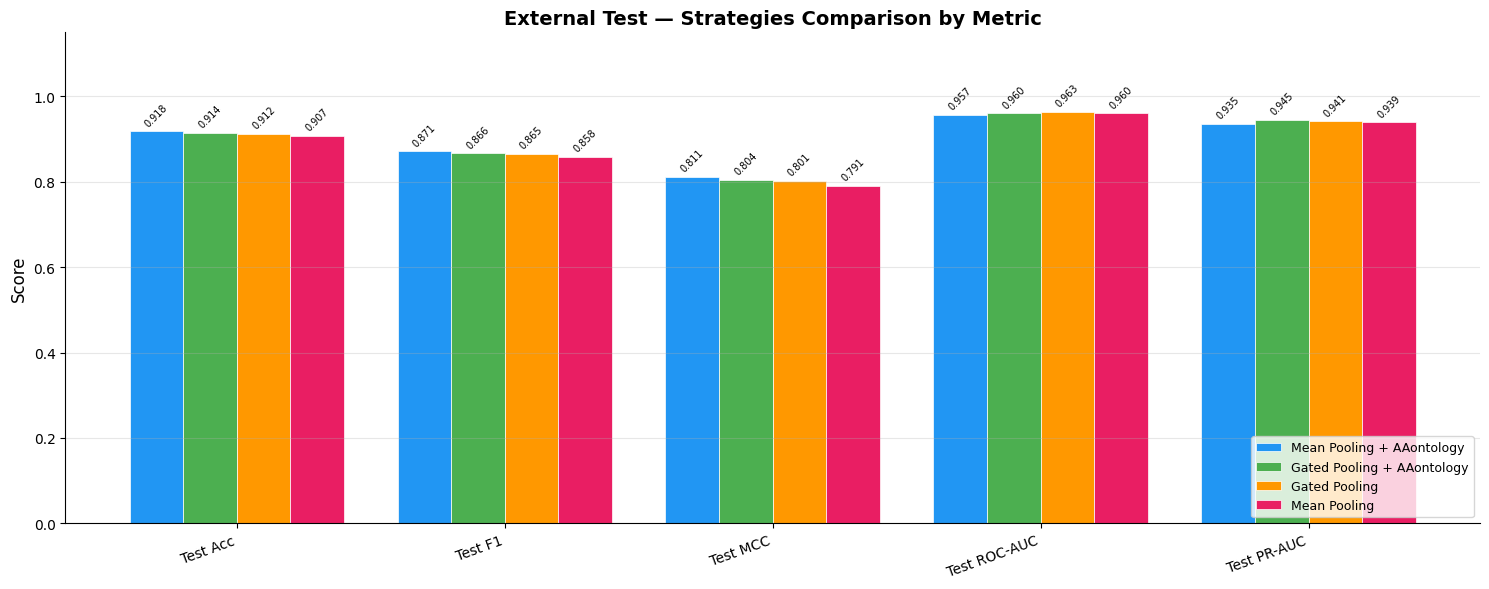

Saved: /kaggle/working/pooling_metrics_bar_chart_transposed.png


In [23]:
metric_cols = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
strategies = results_df["Strategy"].values
n_strategies = len(strategies)

fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(metric_cols))
width = 0.8 / n_strategies

# Colores para cada estrategia 
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"][:n_strategies]

for j, (strategy, color) in enumerate(zip(strategies, colors_bar)):
    # Extraemos los valores de esta estrategia para todas las métricas
    row_vals = results_df.loc[results_df["Strategy"] == strategy, metric_cols].values[0].astype(float)
    
    bars = ax.bar(x + j * width, row_vals, width, label=strategy, color=color, edgecolor="white", linewidth=0.5)
    
    # Añadir etiquetas de valor sobre cada barra
    for bar, v in zip(bars, row_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

# Centrar las etiquetas del eje X 
ax.set_xticks(x + width * (n_strategies - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=20, ha="right", fontsize=10)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("External Test — Strategies Comparison by Metric", fontsize=14, fontweight="bold")

ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(EVAL_DIR / "pooling_metrics_bar_chart_transposed.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'pooling_metrics_bar_chart_transposed.png'}")

## 📉 Superposición de Curvas ROC

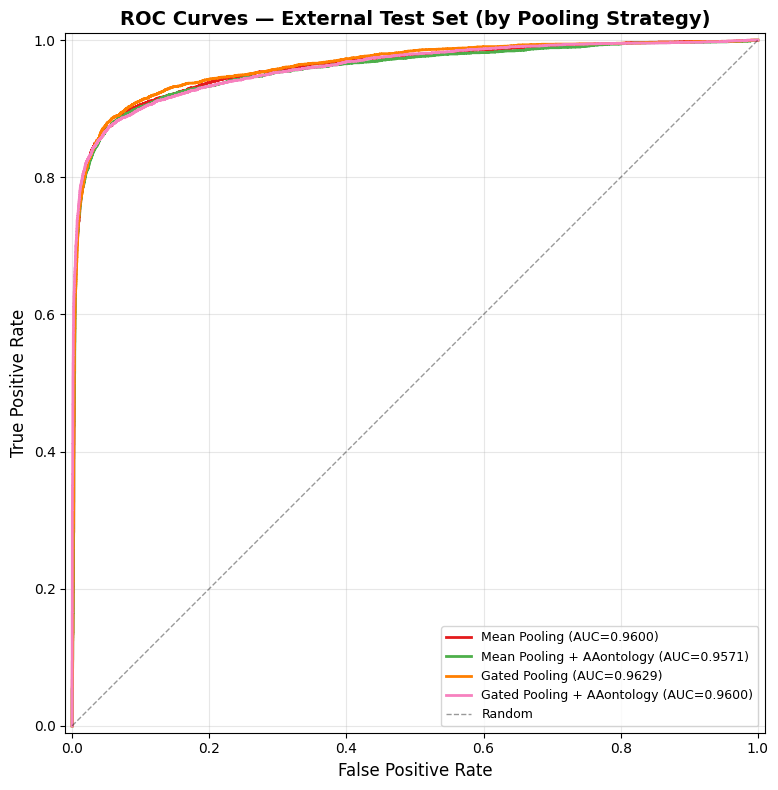

Saved: /kaggle/working/roc_curves_comparison.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
colors_line = plt.cm.Set1(np.linspace(0, 0.8, len(all_eval)))

for idx, r in enumerate(all_eval):
    auc_val = r["test_metrics"]["roc_auc"]
    ax.plot(r["fpr"], r["tpr"],
            label=f"{r['strategy']} (AUC={auc_val:.4f})",
            color=colors_line[idx], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — External Test Set (by Pooling Strategy)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "roc_curves_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'roc_curves_comparison.png'}")

## 🔢 Matrices de Confusión

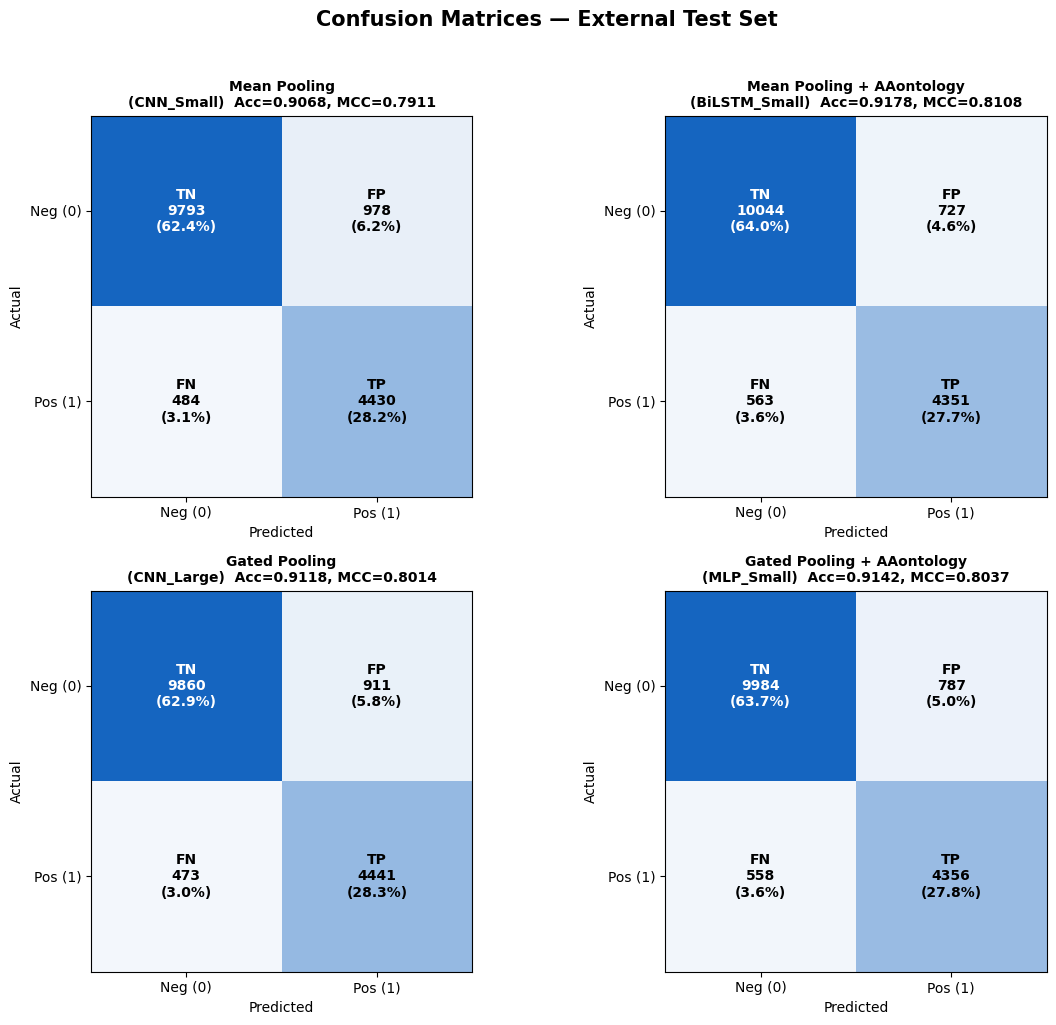

Saved: /kaggle/working/confusion_matrices.png


In [25]:
n_models = len(all_eval)
n_cols = min(2, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
cmap_cm = LinearSegmentedColormap.from_list("custom_blue", ["#ffffff", "#1565C0"])

for idx, r in enumerate(all_eval):
    row_i, col_i = divmod(idx, n_cols)
    ax = axes[row_i][col_i]

    cm_data = r["test_metrics"]["confusion_matrix"]
    cm = np.array([[cm_data["tn"], cm_data["fp"]],
                    [cm_data["fn"], cm_data["tp"]]])

    total = cm.sum()
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap_cm, vmin=0, vmax=cm.max())

    labels_text = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            color = "white" if val > cm.max() * 0.6 else "black"
            ax.text(j, i, f"{labels_text[i][j]}\n{val}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg (0)", "Pos (1)"])
    ax.set_yticklabels(["Neg (0)", "Pos (1)"])
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    acc = r["test_metrics"]["accuracy"]
    mcc = r["test_metrics"]["mcc"]
    ax.set_title(f"{r['strategy']}\n({r['name']})  Acc={acc:.4f}, MCC={mcc:.4f}", fontsize=10, fontweight="bold")

for idx in range(n_models, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

fig.suptitle("Confusion Matrices — External Test Set", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'confusion_matrices.png'}")

## 🕸️ Gráfico de Radar

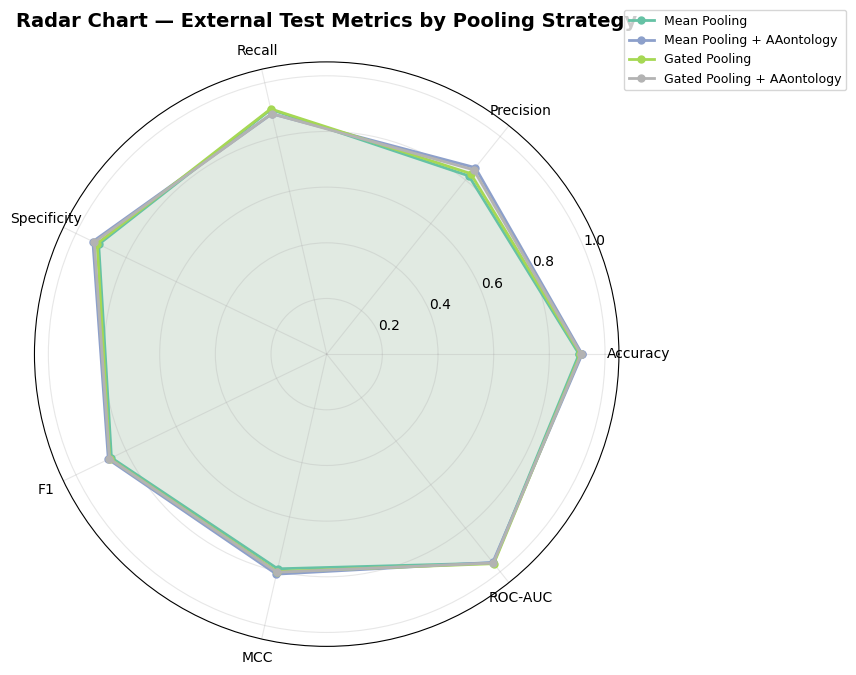

Saved: /kaggle/working/radar_chart.png


In [26]:
radar_metrics = ["accuracy", "precision", "recall", "specificity", "f1", "mcc", "roc_auc"]
radar_labels = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "MCC", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

colors_radar = plt.cm.Set2(np.linspace(0, 0.9, len(all_eval)))

for idx, r in enumerate(all_eval):
    values = [r["test_metrics"].get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=r["strategy"], color=colors_radar[idx], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=colors_radar[idx])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Radar Chart — External Test Metrics by Pooling Strategy", fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'radar_chart.png'}")

## ⚖️ Validación vs Prueba

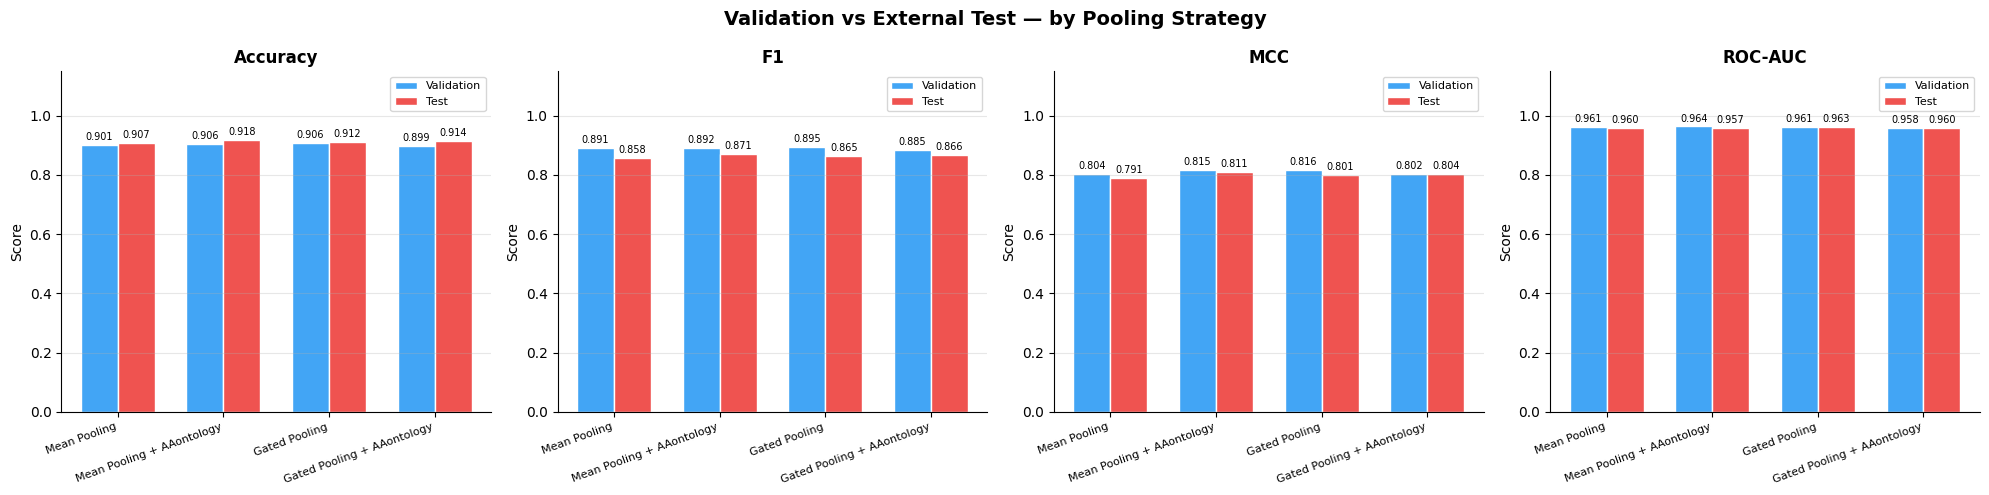

Saved: /kaggle/working/val_vs_test_comparison.png


In [27]:
val_test_metrics = ["accuracy", "f1", "mcc", "roc_auc"]
val_test_labels  = ["Accuracy", "F1", "MCC", "ROC-AUC"]

fig, axes = plt.subplots(1, len(val_test_metrics), figsize=(5 * len(val_test_metrics), 5))

strategy_names = [r["strategy"] for r in all_eval]
x = np.arange(len(strategy_names))
width_vt = 0.35

for ax_idx, (metric_key, metric_label) in enumerate(zip(val_test_metrics, val_test_labels)):
    ax = axes[ax_idx]

    val_vals, test_vals = [], []
    for r in all_eval:
        vm = r.get("val_metrics", {})
        tm = r["test_metrics"]
        val_vals.append(vm.get(metric_key, 0) or 0)
        test_vals.append(tm.get(metric_key, 0) or 0)

    bars1 = ax.bar(x - width_vt / 2, val_vals, width_vt, label="Validation", color="#42A5F5", edgecolor="white")
    bars2 = ax.bar(x + width_vt / 2, test_vals, width_vt, label="Test", color="#EF5350", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Validation vs External Test — by Pooling Strategy", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(EVAL_DIR / "val_vs_test_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'val_vs_test_comparison.png'}")

## 💾 Guardar Todas las Métricas como JSON

In [28]:
all_metrics_json = {}
for r in all_eval:
    all_metrics_json[r["strategy"]] = {
        "model_name": r["name"],
        "config": r["config"],
        "n_params": r["n_params"],
        "best_train_epoch": r["best_train_epoch"],
        "best_val_loss": r["best_val_loss"],
        "val_metrics": r.get("val_metrics", {}),
        "test_metrics": {k: v for k, v in r["test_metrics"].items() if k != "confusion_matrix"},
        "test_confusion_matrix": r["test_metrics"]["confusion_matrix"],
    }

json_path = EVAL_DIR / "pooling_comparison_metrics.json"
with open(json_path, "w") as f:
    json.dump(all_metrics_json, f, indent=2)
print(f"\nSaved: {json_path}")


Saved: /kaggle/working/pooling_comparison_metrics.json


## 🏁 Resumen Final

In [29]:
print("\n" + "=" * 90)
print("EVALUATION SUMMARY — POOLING STRATEGY COMPARISON")
print("=" * 90)
print(f"External test set: ({len(test_ds)} samples) ")
print(f"Strategies evaluated: {len(all_eval)}")
print(f"Threshold: {THRESHOLD}")
print()

print("Final Ranking (by Test MCC):")
for idx, row in results_df.iterrows():
    print(f"  #{idx} {row['Strategy']:28s} ({row['Model']:20s}) | "
          f"Acc={row['Test Acc']:.4f} F1={row['Test F1']:.4f} "
          f"MCC={row['Test MCC']:.4f} AUC={row['Test ROC-AUC']:.4f} "
          f"PR-AUC={row['Test PR-AUC']:.4f}")

print(f"\n🏆 Best strategy on external test: {best_strategy} ({best_entry['name']})")
bm = best_entry["test_metrics"]
print(f"   Acc={bm['accuracy']:.4f} | F1={bm['f1']:.4f} | MCC={bm['mcc']:.4f} | "
      f"AUC={bm['roc_auc']:.4f} | PR-AUC={bm['pr_auc']:.4f}")

print(f"\nOutput directory: {EVAL_DIR.resolve()}")
print("Files generated:")
for f in sorted(EVAL_DIR.glob("*")):
    size = f.stat().st_size
    print(f"  {f.name:45s} ({size / 1024:.1f} KB)")
print("=" * 90)


EVALUATION SUMMARY — POOLING STRATEGY COMPARISON
External test set: (15685 samples) 
Strategies evaluated: 4
Threshold: 0.5

Final Ranking (by Test MCC):
  #1 Mean Pooling + AAontology    (BiLSTM_Small        ) | Acc=0.9178 F1=0.8709 MCC=0.8108 AUC=0.9571 PR-AUC=0.9354
  #2 Gated Pooling + AAontology   (MLP_Small           ) | Acc=0.9142 F1=0.8663 MCC=0.8037 AUC=0.9600 PR-AUC=0.9445
  #3 Gated Pooling                (CNN_Large           ) | Acc=0.9118 F1=0.8652 MCC=0.8014 AUC=0.9629 PR-AUC=0.9413
  #4 Mean Pooling                 (CNN_Small           ) | Acc=0.9068 F1=0.8584 MCC=0.7911 AUC=0.9600 PR-AUC=0.9390

🏆 Best strategy on external test: Mean Pooling + AAontology (BiLSTM_Small)
   Acc=0.9178 | F1=0.8709 | MCC=0.8108 | AUC=0.9571 | PR-AUC=0.9354

Output directory: /kaggle/working
Files generated:
  __notebook__.ipynb                            (600.3 KB)
  confusion_matrices.png                        (201.2 KB)
  pooling_comparison_metrics.json               (4.5 KB)
  pooling_

## 🏆 Conclusión: la mejor estrategia en test externo

Tras evaluar las **4 estrategias de pooling** sobre el mismo test set externo, la combinación **Mean Pooling + AAontology (BiLSTM_Small)** ofrece el mejor equilibrio global en métricas de decisión al umbral 0.5, según **Test MCC**.

### Resultados destacados

| Estrategia | Arquitectura | Params | Test Acc | Test F1 | Test MCC | Test ROC-AUC | Test PR-AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| Mean Pooling + AAontology | BiLSTM_Small | 1,824,065 | **0.9178** | **0.8709** | **0.8108** | 0.9571 | 0.9354 |
| Gated Pooling | CNN_Large | 3,183,490 | 0.9118 | 0.8652 | 0.8014 | **0.9629** | 0.9413 |
| Gated Pooling + AAontology | MLP_Small | 1,125,442 | 0.9142 | 0.8663 | 0.8037 | 0.9600 | **0.9445** |
| Mean Pooling | CNN_Small | 549,953 | 0.9068 | 0.8584 | 0.7911 | 0.9600 | 0.9390 |

### Análisis

- **Métricas de umbral vs. ranking:** `BiLSTM_Small` (Mean + AAontology) gana en MCC/Acc/F1, mientras que las variantes **Gated** lideran en métricas de discriminación (mayor ROC-AUC para `CNN_Large` y mejor PR-AUC para `MLP_Small`). El rango de MCC es estrecho (0.7911–0.8108), por lo que las cuatro estrategias son competitivas.
- **Efecto de AAontology:** sin ontología, Gated supera a Mean en +0.010 MCC (0.8014 vs 0.7911); con ontología, Mean + AAontology supera a Gated + AAontology en +0.007 MCC, sugiriendo que el BiLSTM aprovecha mejor el perfil ontológico por residuo.
- **Salvedad:** cada estrategia se evaluó con su propia arquitectura óptima (CNN, BiLSTM, MLP), así que parte de la diferencia atribuida al *pooling* también refleja el efecto de la arquitectura.

**Estado final:** la combinación **Mean Pooling + AAontology + BiLSTM_Small** se selecciona como la estrategia de referencia por su mejor equilibrio global (Acc/F1/MCC), mientras que las variantes Gated se recomiendan si se prioriza ROC-AUC/PR-AUC.